<a href="https://colab.research.google.com/github/jellybbie/study/blob/invitrosalt/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

file_path = '/content/salt_invitro2_bacil.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,No,Type,Strain,TSB,TSB.1,TSB.2,TSB+200mM NaCl,TSB+200mM NaCl.1,TSB+200mM NaCl.2,TSB+500mM NaCl,...,YPDB.2,YPDB+500mM NaCl,YPDB+500mM NaCl.1,YPDB+500mM NaCl.2,MRS,MRS.1,MRS.2,MRS+500mM NaCl,MRS+500mM NaCl.1,MRS+500mM NaCl.2
0,1,Bacteria,1R-RH9-M1-A6,1.068,1.769,1.543,1.357,1.186,1.770,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Bacteria,1R-RH9-M1-B2,1.076,1.143,1.098,1.218,1.185,1.217,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Bacteria,1R-RH9-M1-B3,1.068,1.130,1.092,1.162,1.179,1.185,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Bacteria,2R-RH6-M1-F5,1.104,1.140,1.068,1.261,1.168,1.188,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Bacteria,2R-RH6-M1-F6,1.078,1.189,1.179,1.228,1.215,1.245,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### OD 값 평균 및 표준 오차 계산

먼저 'Bacillus' 및 'Positive control' 유형의 균주만 필터링합니다. 그런 다음, 각 조건(TSB, TSB+200mM NaCl, TSB+500mM NaCl)에서 측정된 OD 값의 평균과 표준 편차를 계산합니다. 표준 오차(SEM)는 표준 편차를 측정 횟수(3개)의 제곱근으로 나누어 계산합니다.

In [33]:
import numpy as np

# Filter for relevant types: 'Bacillus' and 'Positive control'
filtered_df = df[df['Type'].isin(['Bacillus', 'Positive control'])].copy()

# Define column groups for each condition
tsb_cols = ['TSB', 'TSB.1', 'TSB.2']
nacl200_cols = ['TSB+200mM NaCl', 'TSB+200mM NaCl.1', 'TSB+200mM NaCl.2']
nacl500_cols = ['TSB+500mM NaCl', 'TSB+500mM NaCl.1', 'TSB+500mM NaCl.2']

# Calculate mean, standard deviation, and standard error for TSB condition
filtered_df['mean_TSB'] = filtered_df[tsb_cols].mean(axis=1)
filtered_df['std_TSB'] = filtered_df[tsb_cols].std(axis=1)
filtered_df['sem_TSB'] = filtered_df['std_TSB'] / np.sqrt(filtered_df[tsb_cols].notna().sum(axis=1))

# Calculate mean, standard deviation, and standard error for TSB+200mM NaCl condition
filtered_df['mean_TSB+200mM NaCl'] = filtered_df[nacl200_cols].mean(axis=1)
filtered_df['std_TSB+200mM NaCl'] = filtered_df[nacl200_cols].std(axis=1)
filtered_df['sem_TSB+200mM NaCl'] = filtered_df['std_TSB+200mM NaCl'] / np.sqrt(filtered_df[nacl200_cols].notna().sum(axis=1))

# Calculate mean, standard deviation, and standard error for TSB+500mM NaCl condition
filtered_df['mean_TSB+500mM NaCl'] = filtered_df[nacl500_cols].mean(axis=1)
filtered_df['std_TSB+500mM NaCl'] = filtered_df[nacl500_cols].std(axis=1)
filtered_df['sem_TSB+500mM NaCl'] = filtered_df['std_TSB+500mM NaCl'] / np.sqrt(filtered_df[nacl500_cols].notna().sum(axis=1))

# Display the intermediate results (mean, std, sem for each condition)
display(filtered_df[['Type', 'Strain', 'mean_TSB', 'sem_TSB', 'mean_TSB+200mM NaCl', 'sem_TSB+200mM NaCl', 'mean_TSB+500mM NaCl', 'sem_TSB+500mM NaCl']].head())

,Type,Strain,mean_TSB,sem_TSB,mean_TSB+200mM NaCl,sem_TSB+200mM NaCl,mean_TSB+500mM NaCl,sem_TSB+500mM NaCl
44,Bacillus,GI-12,1.472333,0.156659,1.061333,0.026434,0.837333,0.019911
45,Bacillus,GI-14,1.089333,0.019125,1.101000,0.011930,0.725667,0.019376
46,Bacillus,GO-9,1.684667,0.005175,1.069333,0.018853,0.735000,0.014742
47,Bacillus,GO-16,1.101000,0.006658,1.054333,0.014667,0.729333,0.026535
48,Bacillus,YD-4,1.711000,0.018037,0.993000,0.023516,0.663333,0.058516


### TSB 대비 상대적 OD 값 및 표준 오차 계산

TSB에서 배양한 OD 값을 기준으로 TSB+200mM NaCl 및 TSB+500mM NaCl 조건에서의 상대적 OD 값을 계산합니다. 상대적 OD 값은 각 조건의 평균 OD 값을 TSB 조건의 평균 OD 값으로 나누어 구합니다. 상대적 OD 값의 표준 오차는 오차 전파 공식을 사용하여 계산합니다.

In [34]:
# Calculate relative OD values: (OD at NaCl condition) / (OD at TSB condition)
filtered_df['Relative_OD_200mM_NaCl'] = filtered_df['mean_TSB+200mM NaCl'] / filtered_df['mean_TSB']
filtered_df['Relative_OD_500mM_NaCl'] = filtered_df['mean_TSB+500mM NaCl'] / filtered_df['mean_TSB']

# Calculate standard error of the relative OD using error propagation for division
# If Z = A/B, then SE_Z = Z * sqrt((SE_A/A)^2 + (SE_B/B)^2)

# For Relative_OD_200mM_NaCl_SEM
# Avoid division by zero if mean_TSB or mean_TSB+200mM NaCl is zero
term_A_200 = np.where(filtered_df['mean_TSB+200mM NaCl'] != 0, (filtered_df['sem_TSB+200mM NaCl'] / filtered_df['mean_TSB+200mM NaCl'])**2, np.nan)
term_B_200 = np.where(filtered_df['mean_TSB'] != 0, (filtered_df['sem_TSB'] / filtered_df['mean_TSB'])**2, np.nan)
filtered_df['Relative_OD_200mM_NaCl_SEM'] = filtered_df['Relative_OD_200mM_NaCl'] * np.sqrt(term_A_200 + term_B_200)

# For Relative_OD_500mM_NaCl_SEM
term_A_500 = np.where(filtered_df['mean_TSB+500mM NaCl'] != 0, (filtered_df['sem_TSB+500mM NaCl'] / filtered_df['mean_TSB+500mM NaCl'])**2, np.nan)
term_B_500 = np.where(filtered_df['mean_TSB'] != 0, (filtered_df['sem_TSB'] / filtered_df['mean_TSB'])**2, np.nan)
filtered_df['Relative_OD_500mM_NaCl_SEM'] = filtered_df['Relative_OD_500mM_NaCl'] * np.sqrt(term_A_500 + term_B_500)

# Select relevant columns for final display
result_df = filtered_df[['Type', 'Strain',
                         'mean_TSB', 'sem_TSB',
                         'Relative_OD_200mM_NaCl', 'Relative_OD_200mM_NaCl_SEM',
                         'Relative_OD_500mM_NaCl', 'Relative_OD_500mM_NaCl_SEM']].copy()

# Drop rows where 'mean_TSB' is NaN, as these cannot be used as a baseline
result_df.dropna(subset=['mean_TSB'], inplace=True)

display(result_df)

,Type,Strain,mean_TSB,sem_TSB,Relative_OD_200mM_NaCl,Relative_OD_200mM_NaCl_SEM,Relative_OD_500mM_NaCl,Relative_OD_500mM_NaCl_SEM
44,Bacillus,GI-12,1.472333,0.156659,0.720851,0.078773,0.568712,0.062005
45,Bacillus,GI-14,1.089333,0.019125,1.010710,0.020853,0.666157,0.021288
46,Bacillus,GO-9,1.684667,0.005175,0.634745,0.011360,0.436288,0.008853
47,Bacillus,GO-16,1.101000,0.006658,0.957614,0.014526,0.662428,0.024432
48,Bacillus,YD-4,1.711000,0.018037,0.580362,0.015044,0.387688,0.034443
49,Bacillus,KJ-11,1.033000,0.008660,0.953211,0.017584,0.742498,0.039366
50,Bacillus,KJ-14,0.946667,0.002333,0.987676,0.023909,0.809155,0.039240
51,Bacillus,KJ-22,1.689333,0.020218,0.544199,0.006831,0.410418,0.033024
52,Bacillus,KL3-3,1.042667,0.011624,0.926790,0.013109,0.649936,0.019558
53,Bacillus,KS1,1.734333,0.026959,0.524121,0.017104,0.421295,0.012864


### 'Bacteria' 및 'Positive control'에 대한 TSB+200mM NaCl 조건 상대적 OD 막대 그래프

### 'Bacillus' 균주에 대한 TSB 대비 상대적 OD 값 및 표준 오차 (다시 표시)

In [35]:
# Display the result_df containing relative OD values and their SEMs for Bacillus
display(result_df[result_df['Type'] == 'Bacillus'])

,Type,Strain,mean_TSB,sem_TSB,Relative_OD_200mM_NaCl,Relative_OD_200mM_NaCl_SEM,Relative_OD_500mM_NaCl,Relative_OD_500mM_NaCl_SEM
44,Bacillus,GI-12,1.472333,0.156659,0.720851,0.078773,0.568712,0.062005
45,Bacillus,GI-14,1.089333,0.019125,1.010710,0.020853,0.666157,0.021288
46,Bacillus,GO-9,1.684667,0.005175,0.634745,0.011360,0.436288,0.008853
47,Bacillus,GO-16,1.101000,0.006658,0.957614,0.014526,0.662428,0.024432
48,Bacillus,YD-4,1.711000,0.018037,0.580362,0.015044,0.387688,0.034443
49,Bacillus,KJ-11,1.033000,0.008660,0.953211,0.017584,0.742498,0.039366
50,Bacillus,KJ-14,0.946667,0.002333,0.987676,0.023909,0.809155,0.039240
51,Bacillus,KJ-22,1.689333,0.020218,0.544199,0.006831,0.410418,0.033024
52,Bacillus,KL3-3,1.042667,0.011624,0.926790,0.013109,0.649936,0.019558
53,Bacillus,KS1,1.734333,0.026959,0.524121,0.017104,0.421295,0.012864


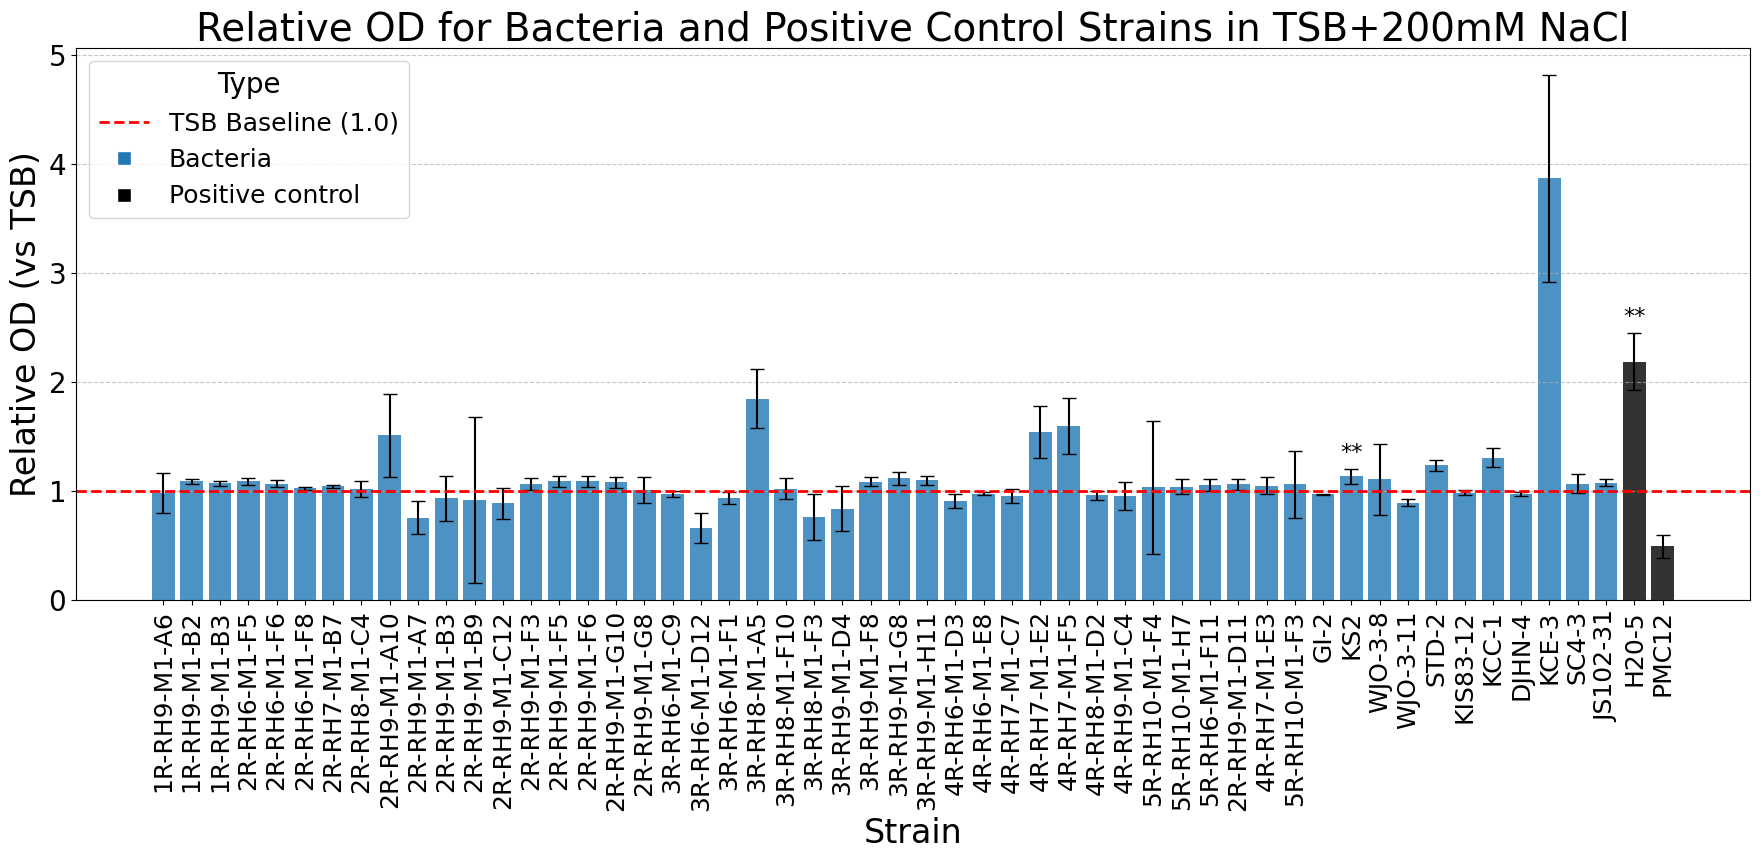

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting for TSB+200mM NaCl (Relative) condition
# Filter plot_data for only the 'TSB+200mM NaCl (Relative)' condition
plot_data_bacteria_200 = result_df[['Type', 'Strain', 'Relative_OD_200mM_NaCl', 'Relative_OD_200mM_NaCl_SEM']].copy()
plot_data_bacteria_200.rename(columns={'Relative_OD_200mM_NaCl': 'Relative_OD', 'Relative_OD_200mM_NaCl_SEM': 'Relative_SEM'}, inplace=True)
plot_data_bacteria_200['Condition'] = 'TSB+200mM NaCl (Relative)'

# --- Custom Sorting for Strains ---
# Get unique Bacteria strains and Positive control strains
bacteria_strains = plot_data_bacteria_200[plot_data_bacteria_200['Type'] == 'Bacteria']['Strain'].unique().tolist()
positive_control_strains = plot_data_bacteria_200[plot_data_bacteria_200['Type'] == 'Positive control']['Strain'].unique().tolist()

# Combine them to form the custom order
custom_strain_order_bacteria = bacteria_strains + positive_control_strains

# Convert 'Strain' column to a categorical type with the custom order
plot_data_bacteria_200['Strain'] = pd.Categorical(plot_data_bacteria_200['Strain'], categories=custom_strain_order_bacteria, ordered=True)

# Sort plot_data by the new categorical 'Strain' column
plot_data_bacteria_200 = plot_data_bacteria_200.sort_values(by=['Strain']).reset_index(drop=True)
# --- End Custom Sorting ---

# Get unique strains (now ordered according to custom_strain_order_bacteria)
strains_to_plot = plot_data_bacteria_200['Strain'].unique()
bar_width = 0.8 # Width of each bar
index_positions = np.arange(len(strains_to_plot)) # X-axis positions for each strain

# Set a global font size for better readability
plt.rcParams.update({'font.size': 20}) # Doubled the default font size (often 10)

fig, ax = plt.subplots(figsize=(18, 9))

# Define default color for Bacteria strains (using a blue shade)
default_bacteria_color = sns.color_palette('tab10')[0]

# Create a map for strain type for efficient lookup (from the current result_df)
strain_type_map = result_df.set_index('Strain')['Type'].to_dict()

# Variables to track if 'Bacteria' or 'Positive control' bars were actually plotted
plotted_bacteria = False
plotted_positive_control = False

for i, strain in enumerate(strains_to_plot):
    if strain in plot_data_bacteria_200['Strain'].values:
        strain_data = plot_data_bacteria_200[plot_data_bacteria_200['Strain'] == strain].iloc[0]
        strain_od = strain_data['Relative_OD']
        strain_sem = strain_data['Relative_SEM']
        strain_type = strain_type_map.get(strain) # Get type from the map

        # Determine bar color
        if strain_type == 'Positive control':
            bar_color = 'black'
            plotted_positive_control = True
        else:
            bar_color = default_bacteria_color
            plotted_bacteria = True

        # Plot individual bar
        ax.bar(
            index_positions[i], # X-position for the current strain
            strain_od,
            bar_width,
            yerr=strain_sem,
            capsize=5,
            color=bar_color,
            alpha=0.8
        )

        # Add significance markers using ttest_results_df_per_strain
        if strain in ttest_results_df_per_strain['Strain'].values:
            p_value_entry = ttest_results_df_per_strain[ttest_results_df_per_strain['Strain'] == strain]['P_Value'].iloc[0]
            p_value = float(p_value_entry) if pd.notna(p_value_entry) else 1.0

            significance_text = ''
            if p_value < 0.001:
                significance_text = '***'
            elif p_value < 0.01:
                significance_text = '**'
            elif p_value < 0.05:
                significance_text = '*'

            bar_x = index_positions[i]
            bar_y = strain_od + strain_sem + 0.05 # Slightly above the error bar
            ax.text(bar_x, bar_y, significance_text, ha='center', va='bottom', fontsize=16, color='black')

# Set labels and title
ax.set_xlabel('Strain', fontsize=24)
ax.set_ylabel('Relative OD (vs TSB)', fontsize=24)
ax.set_title('Relative OD for Bacteria and Positive Control Strains in TSB+200mM NaCl', fontsize=28)
ax.set_xticks(index_positions)
ax.set_xticklabels(strains_to_plot, rotation=90, ha='center', fontsize=18)

# Add TSB Baseline line
baseline_line = ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='TSB Baseline (1.0)')

# Create custom legend handles and labels
legend_handles = [baseline_line]
legend_labels = ['TSB Baseline (1.0)']

# Add a dummy bar handle for Bacteria strains if any were plotted
if plotted_bacteria:
    bacteria_patch = plt.Line2D([0], [0], marker='s', color='w',
                                markerfacecolor=default_bacteria_color,
                                label='Bacteria', markersize=10)
    legend_handles.append(bacteria_patch)
    legend_labels.append('Bacteria')

# Add a dummy bar handle for Positive Control strains if any were plotted
if plotted_positive_control:
    positive_control_patch = plt.Line2D([0], [0], marker='s', color='w',
                                        markerfacecolor='black',
                                        label='Positive control', markersize=10)
    legend_handles.append(positive_control_patch)
    legend_labels.append('Positive control')

ax.legend(legend_handles, legend_labels, title='Type', fontsize=18, title_fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 상대적 OD 값 시각화

TSB를 기준으로 계산된 TSB+200mM NaCl 및 TSB+500mM NaCl 조건에서의 상대적 OD 값을 막대 그래프로 시각화합니다. 각 막대에는 계산된 표준 오차를 오차 막대로 표시하여 데이터의 변동성을 함께 나타냅니다.

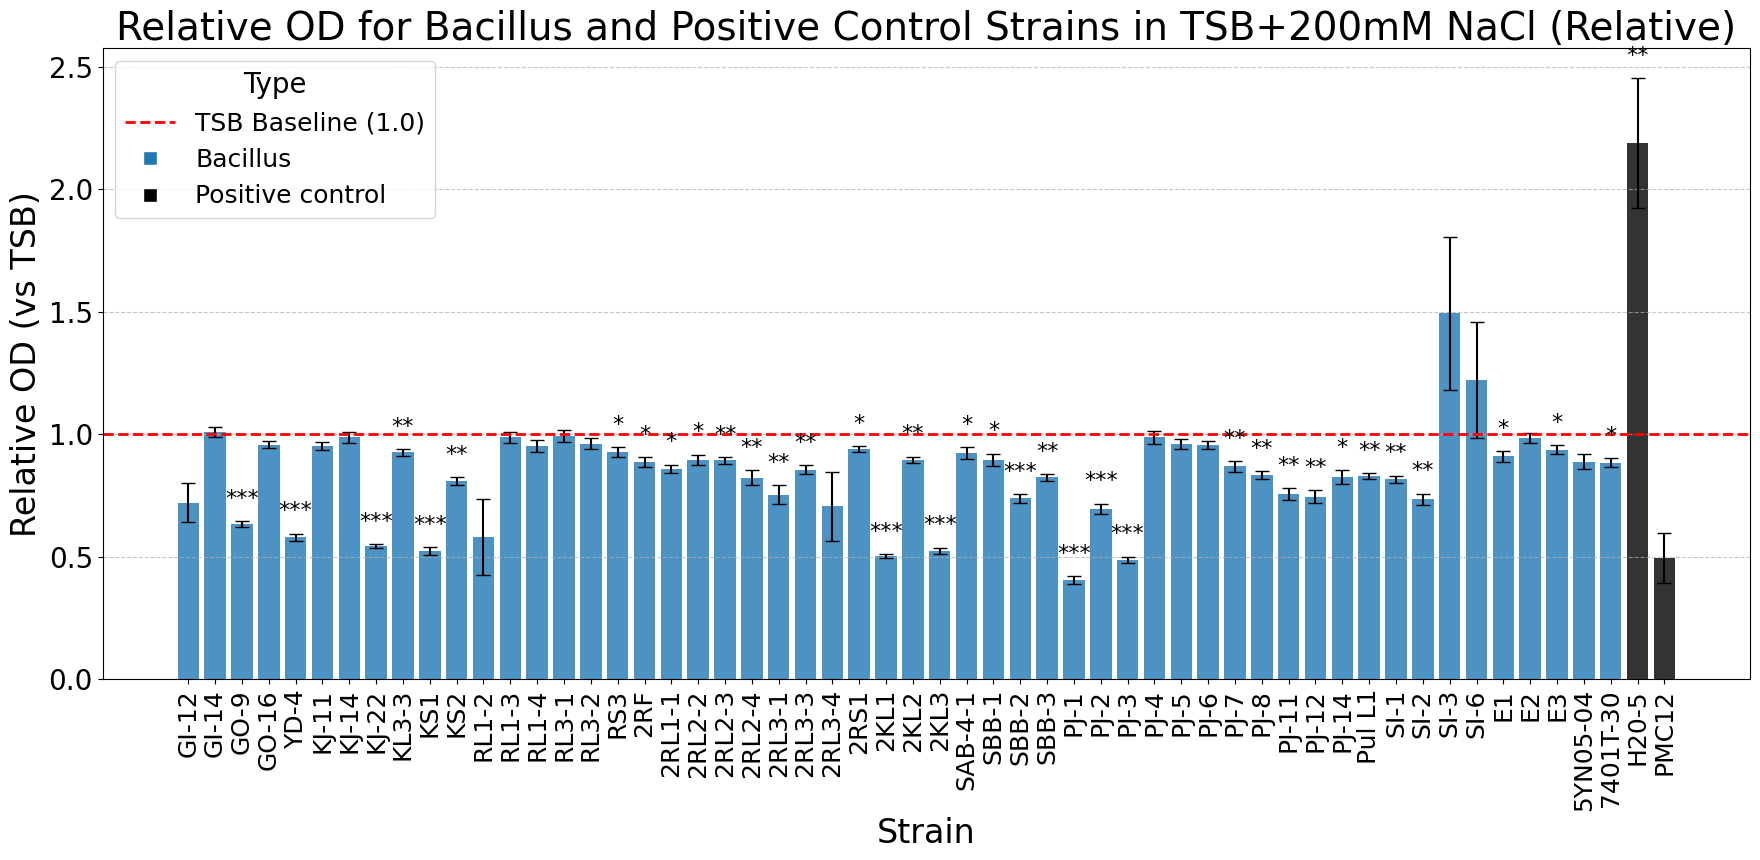

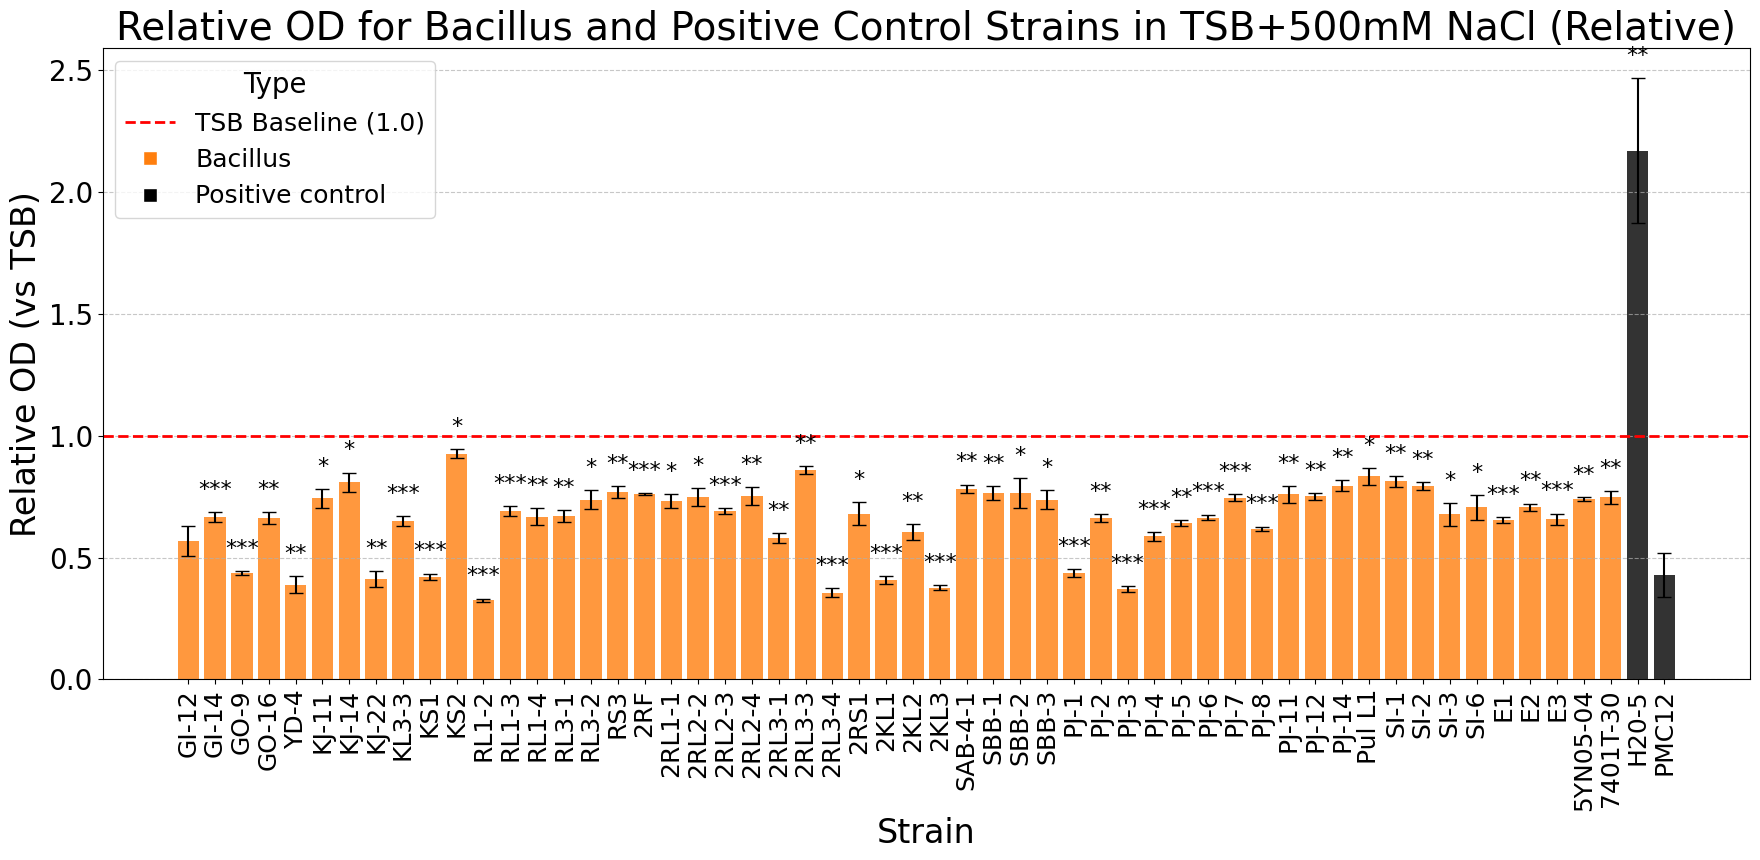

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
# Melt the relative OD columns into a long format
plot_data = result_df.melt(
    id_vars=['Type', 'Strain'],
    value_vars=['Relative_OD_200mM_NaCl', 'Relative_OD_500mM_NaCl'],
    var_name='Condition',
    value_name='Relative_OD'
)

# Melt the corresponding SEM columns
sem_data = result_df.melt(
    id_vars=['Type', 'Strain'],
    value_vars=['Relative_OD_200mM_NaCl_SEM', 'Relative_OD_500mM_NaCl_SEM'],
    var_name='Condition_SEM',
    value_name='Relative_SEM'
)

# Align condition names for merging SEM data
sem_data['Condition'] = sem_data['Condition_SEM'].replace({
    'Relative_OD_200mM_NaCl_SEM': 'Relative_OD_200mM_NaCl',
    'Relative_OD_500mM_NaCl_SEM': 'Relative_OD_500mM_NaCl'
})

# Merge relative OD values with their corresponding SEMs
plot_data = pd.merge(
    plot_data,
    sem_data[['Type', 'Strain', 'Condition', 'Relative_SEM']],
    on=['Type', 'Strain', 'Condition'],
    how='left'
)

# Replace column names for better readability in the plot legend
plot_data['Condition'] = plot_data['Condition'].replace({
    'Relative_OD_200mM_NaCl': 'TSB+200mM NaCl (Relative)',
    'Relative_OD_500mM_NaCl': 'TSB+500mM NaCl (Relative)'
})

# --- Custom Sorting for Strains ---
# Get unique Bacillus strains and Positive control strains, maintaining original order from result_df
bacillus_strains = result_df[result_df['Type'] == 'Bacillus']['Strain'].unique().tolist()
positive_control_strains = result_df[result_df['Type'] == 'Positive control']['Strain'].unique().tolist()

# Combine them to form the custom order
custom_strain_order = bacillus_strains + positive_control_strains

# Convert 'Strain' column to a categorical type with the custom order
plot_data['Strain'] = pd.Categorical(plot_data['Strain'], categories=custom_strain_order, ordered=True)

# Sort plot_data by the new categorical 'Strain' column
plot_data = plot_data.sort_values(by=['Strain']).reset_index(drop=True)
# --- End Custom Sorting ---

# Set a global font size for better readability
plt.rcParams.update({'font.size': 20}) # Doubled the default font size (often 10)

# Get unique strains (now ordered according to custom_strain_order)
strains = plot_data['Strain'].unique()
bar_width = 0.8 # Width of each bar for single plots
index_positions = np.arange(len(strains)) # X-axis positions for each strain

# Create a map for strain type for efficient lookup
strain_type_map = result_df.set_index('Strain')['Type'].to_dict()

# Define default colors for conditions (for Bacillus strains)
default_condition_colors = {
    'TSB+200mM NaCl (Relative)': sns.color_palette('tab10')[0], # Blue
    'TSB+500mM NaCl (Relative)': sns.color_palette('tab10')[1]  # Orange
}

# List of conditions to plot separately
conditions_to_plot = ['TSB+200mM NaCl (Relative)', 'TSB+500mM NaCl (Relative)']

for condition in conditions_to_plot:
    fig, ax = plt.subplots(figsize=(18, 9))

    # Filter data for the current condition and set Strain as index for faster lookup
    condition_data = plot_data[plot_data['Condition'] == condition].set_index('Strain')

    # Prepare t-test data for significance markers
    if condition == 'TSB+200mM NaCl (Relative)':
        ttest_data_for_condition = ttest_results_df_per_strain.set_index('Strain')
    elif condition == 'TSB+500mM NaCl (Relative)':
        ttest_data_for_condition = ttest_results_df_per_strain_500.set_index('Strain')
    else:
        ttest_data_for_condition = pd.DataFrame() # Should not happen

    # Variables to track if 'Bacillus' or 'Positive control' bars were actually plotted
    # This helps in deciding whether to add their patches to the legend
    plotted_bacillus = False
    plotted_positive_control = False

    for i, strain in enumerate(strains):
        if strain in condition_data.index:
            strain_od = condition_data.loc[strain, 'Relative_OD']
            strain_sem = condition_data.loc[strain, 'Relative_SEM']
            strain_type = strain_type_map.get(strain) # Get type from the map

            # Determine bar color
            if strain_type == 'Positive control':
                bar_color = 'black'
                plotted_positive_control = True
            else:
                bar_color = default_condition_colors[condition]
                plotted_bacillus = True

            # Plot individual bar
            ax.bar(
                index_positions[i], # X-position for the current strain
                strain_od,
                bar_width,
                yerr=strain_sem,
                capsize=5,
                color=bar_color,
                alpha=0.8
            )

            # Add significance markers
            if strain in ttest_data_for_condition.index:
                p_value_str = ttest_data_for_condition.loc[strain, 'P_Value']
                p_value = float(p_value_str) if pd.notna(p_value_str) else 1.0

                significance_text = ''
                if p_value < 0.001:
                    significance_text = '***'
                elif p_value < 0.01:
                    significance_text = '**'
                elif p_value < 0.05:
                    significance_text = '*'

                bar_x = index_positions[i]
                bar_y = strain_od + strain_sem + 0.05 # Slightly above the error bar
                ax.text(bar_x, bar_y, significance_text, ha='center', va='bottom', fontsize=16, color='black')

    # Set labels and title
    ax.set_xlabel('Strain', fontsize=24)
    ax.set_ylabel('Relative OD (vs TSB)', fontsize=24)
    ax.set_title(f'Relative OD for Bacillus and Positive Control Strains in {condition}', fontsize=28)
    ax.set_xticks(index_positions)
    ax.set_xticklabels(strains, rotation=90, ha='center', fontsize=18)

    # Add TSB Baseline line
    baseline_line = ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='TSB Baseline (1.0)')

    # Create custom legend handles and labels
    legend_handles = [baseline_line]
    legend_labels = ['TSB Baseline (1.0)']

    # Add a dummy bar handle for Bacillus strains if any were plotted
    if plotted_bacillus:
        bacillus_patch = plt.Line2D([0], [0], marker='s', color='w',
                                    markerfacecolor=default_condition_colors[condition],
                                    label='Bacillus', markersize=10)
        legend_handles.append(bacillus_patch)
        legend_labels.append('Bacillus')

    # Add a dummy bar handle for Positive Control strains if any were plotted
    if plotted_positive_control:
        positive_control_patch = plt.Line2D([0], [0], marker='s', color='w',
                                            markerfacecolor='black',
                                            label='Positive control', markersize=10)
        legend_handles.append(positive_control_patch)
        legend_labels.append('Positive control')

    ax.legend(legend_handles, legend_labels, title='Type', fontsize=18, title_fontsize=20)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Reset global font size to default if needed for subsequent plots
# plt.rcParams.update({'font.size': 10})

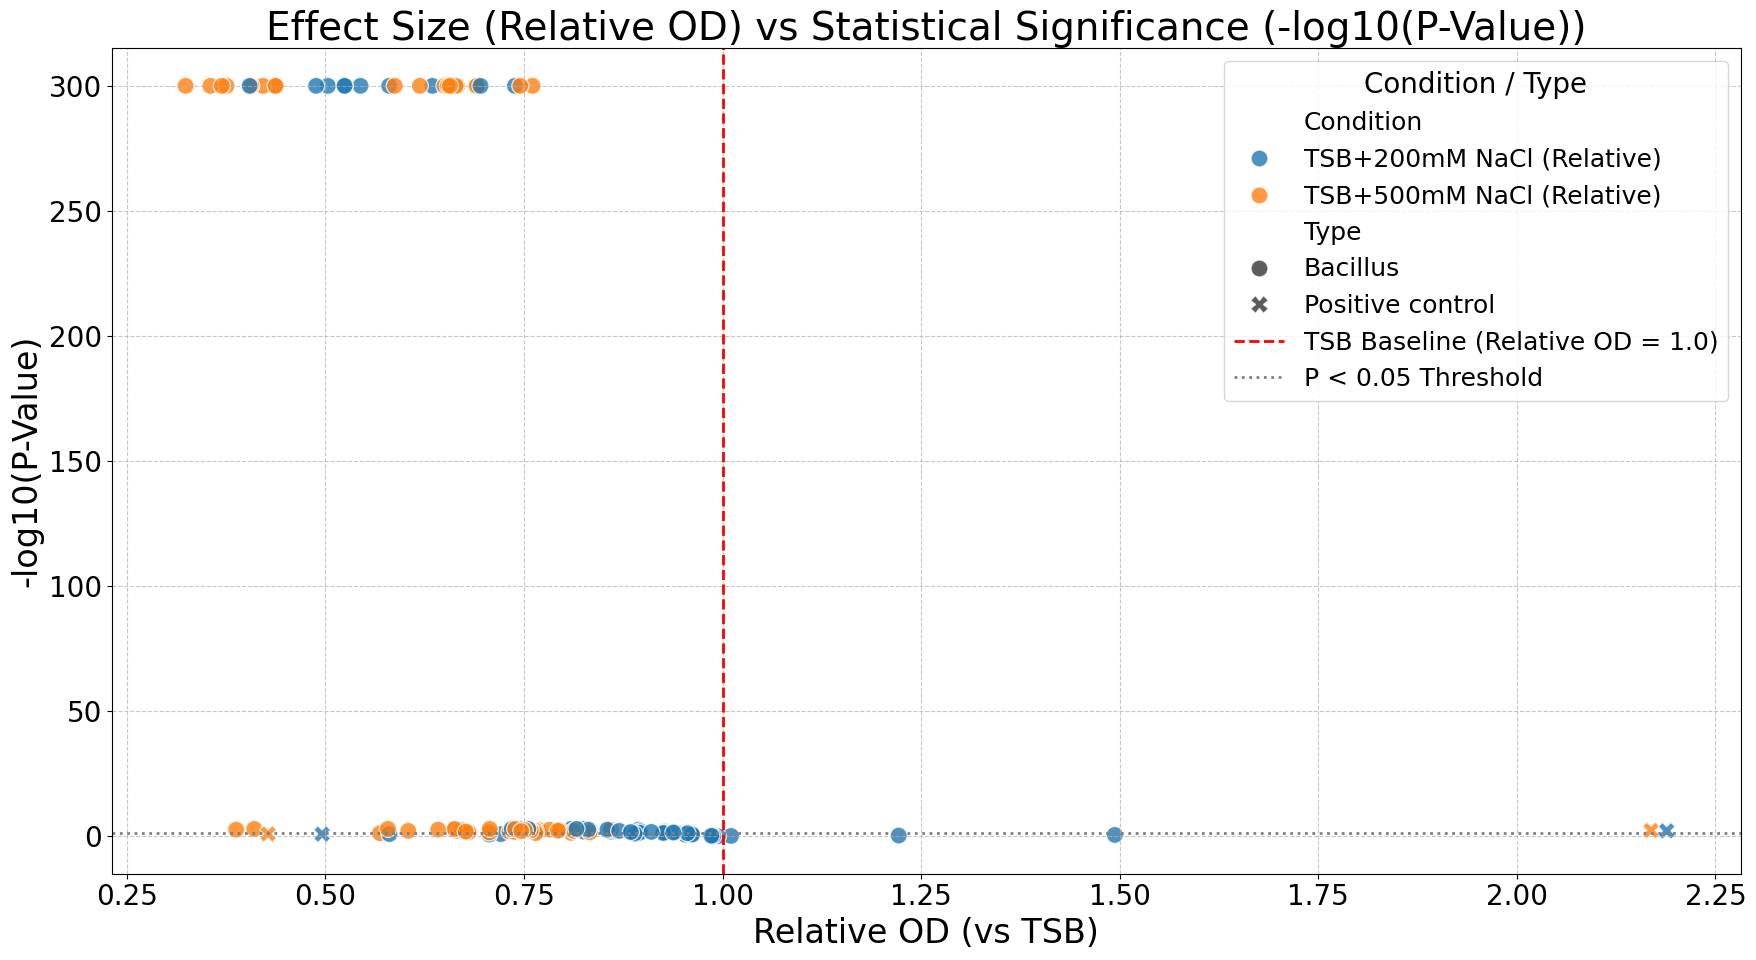

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare P-value data for merging
ttest_200_df = ttest_results_df_per_strain.copy()
ttest_200_df['Condition'] = 'TSB+200mM NaCl (Relative)'
ttest_500_df = ttest_results_df_per_strain_500.copy()
ttest_500_df['Condition'] = 'TSB+500mM NaCl (Relative)'

# Combine t-test results for both conditions
combined_ttest_df = pd.concat([ttest_200_df, ttest_500_df])

# Convert P_Value to numeric, coercing errors to NaN
combined_ttest_df['P_Value'] = pd.to_numeric(combined_ttest_df['P_Value'], errors='coerce')

# Merge plot_data with combined t-test results
# We need to ensure 'Strain' column in plot_data is not categorical during merge for consistency
plot_data_non_cat = plot_data.copy()
plot_data_non_cat['Strain'] = plot_data_non_cat['Strain'].astype(str)

merged_plot_and_ttest = pd.merge(
    plot_data_non_cat,
    combined_ttest_df[['Strain', 'Condition', 'P_Value']],
    on=['Strain', 'Condition'],
    how='left'
)

# Calculate -log10(P_Value) for visualization. Handle P_Value = 0 by replacing with a very small number
# For visualization purposes, if p-value is 0, set it to a very small number to avoid log(0)
merged_plot_and_ttest['P_Value_for_log'] = merged_plot_and_ttest['P_Value'].replace(0, 1e-300) # Use a very small number
merged_plot_and_ttest['-log10(P_Value)'] = -np.log10(merged_plot_and_ttest['P_Value_for_log'])

# Set a global font size for better readability
plt.rcParams.update({'font.size': 20})

# Create the scatter plot (Volcano Plot-like)
fig, ax = plt.subplots(figsize=(18, 10))
sns.scatterplot(
    data=merged_plot_and_ttest,
    x='Relative_OD',
    y='-log10(P_Value)',
    hue='Condition',
    style='Type', # Differentiate Bacillus vs Positive control by marker style
    s=150, # Marker size
    alpha=0.8, # Transparency
    ax=ax
)

# Add reference lines
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='TSB Baseline (Relative OD = 1.0)')
ax.axhline(-np.log10(0.05), color='gray', linestyle=':', linewidth=2, label='P < 0.05 Threshold')

# Add labels and title
ax.set_xlabel('Relative OD (vs TSB)', fontsize=24)
ax.set_ylabel('-log10(P-Value)', fontsize=24)
ax.set_title('Effect Size (Relative OD) vs Statistical Significance (-log10(P-Value))', fontsize=28)

# Add legend with increased font size
ax.legend(title='Condition / Type', fontsize=18, title_fontsize=20)

# Add grid for readability
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [21]:
from scipy import stats

# Extract the mean OD values for TSB and TSB+200mM NaCl conditions
tsb_values = filtered_df['mean_TSB']
nacl200_values = filtered_df['mean_TSB+200mM NaCl']

# Perform a paired t-test
# We use the mean values for each strain as the observations for the t-test
t_statistic, p_value = stats.ttest_rel(tsb_values, nacl200_values)

print(f"Paired t-test between TSB and TSB+200mM NaCl:")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"Conclusion: Since the p-value ({p_value:.3f}) is less than {alpha}, we reject the null hypothesis.\nThere is a statistically significant difference between the mean OD values of TSB and TSB+200mM NaCl conditions.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.3f}) is greater than {alpha}, we fail to reject the null hypothesis.\nThere is no statistically significant difference between the mean OD values of TSB and TSB+200mM NaCl conditions.")

Paired t-test between TSB and TSB+200mM NaCl:
T-statistic: 5.465
P-value: 0.000
Conclusion: Since the p-value (0.000) is less than 0.05, we reject the null hypothesis.
There is a statistically significant difference between the mean OD values of TSB and TSB+200mM NaCl conditions.


In [22]:
from scipy import stats

# Get all unique strains
unique_strains = filtered_df['Strain'].unique()
ttest_results_per_strain = []

# Define raw OD columns for TSB and TSB+200mM NaCl
tsb_raw_cols = ['TSB', 'TSB.1', 'TSB.2']
nacl200_raw_cols = ['TSB+200mM NaCl', 'TSB+200mM NaCl.1', 'TSB+200mM NaCl.2']

print("--- T-test Results (TSB vs TSB+200mM NaCl for each Strain) ---")
print("--------------------------------------------------------------")

for strain in unique_strains:
    strain_data = filtered_df[filtered_df['Strain'] == strain]

    # Extract raw replicate values for TSB and TSB+200mM NaCl
    tsb_replicates = strain_data[tsb_raw_cols].values.flatten()
    nacl200_replicates = strain_data[nacl200_raw_cols].values.flatten()

    # Ensure there are no NaN values that would prevent t-test calculation
    tsb_replicates = tsb_replicates[~np.isnan(tsb_replicates)]
    nacl200_replicates = nacl200_replicates[~np.isnan(nacl200_replicates)]

    # Only proceed if both conditions have at least 2 valid replicates (t-test requires at least 2 for each group)
    if len(tsb_replicates) >= 2 and len(nacl200_replicates) >= 2:
        # Perform independent samples t-test (Welch's t-test by setting equal_var=False)
        # Welch's t-test is more robust when sample sizes are small or variances are unequal
        t_statistic, p_value = stats.ttest_ind(tsb_replicates, nacl200_replicates, equal_var=False)

        ttest_results_per_strain.append({
            'Strain': strain,
            'T_Statistic': f'{t_statistic:.3f}',
            'P_Value': f'{p_value:.3f}'
        })
        print(f"Strain: {strain}, T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")
        alpha = 0.05
        if p_value < alpha:
            print(f"  -> Statistically significant difference (p < {alpha})")
        else:
            print(f"  -> No statistically significant difference (p >= {alpha})")
    else:
        print(f"Strain: {strain}, Not enough data for t-test (TSB replicates: {len(tsb_replicates)}, TSB+200mM NaCl replicates: {len(nacl200_replicates)})")

# Convert results to DataFrame for better display
ttest_results_df_per_strain = pd.DataFrame(ttest_results_per_strain)

print("\n--- Summary of T-test Results ---")
display(ttest_results_df_per_strain)

--- T-test Results (TSB vs TSB+200mM NaCl for each Strain) ---
--------------------------------------------------------------
Strain: GI-12, T-statistic: 2.587, P-value: 0.116
  -> No statistically significant difference (p >= 0.05)
Strain: GI-14, T-statistic: -0.518, P-value: 0.637
  -> No statistically significant difference (p >= 0.05)
Strain: GO-9, T-statistic: 31.474, P-value: 0.000
  -> Statistically significant difference (p < 0.05)
Strain: GO-16, T-statistic: 2.897, P-value: 0.068
  -> No statistically significant difference (p >= 0.05)
Strain: YD-4, T-statistic: 24.227, P-value: 0.000
  -> Statistically significant difference (p < 0.05)
Strain: KJ-11, T-statistic: 2.634, P-value: 0.076
  -> No statistically significant difference (p >= 0.05)
Strain: KJ-14, T-statistic: 0.515, P-value: 0.657
  -> No statistically significant difference (p >= 0.05)
Strain: KJ-22, T-statistic: 37.532, P-value: 0.000
  -> Statistically significant difference (p < 0.05)
Strain: KL3-3, T-statistic: 

,Strain,T_Statistic,P_Value
0,GI-12,2.587,0.116
1,GI-14,-0.518,0.637
2,GO-9,31.474,0.000
3,GO-16,2.897,0.068
4,YD-4,24.227,0.000
5,KJ-11,2.634,0.076
6,KJ-14,0.515,0.657
7,KJ-22,37.532,0.000
8,KL3-3,5.320,0.008
9,KS1,22.002,0.000


In [24]:
from scipy import stats

# Get all unique strains
unique_strains_500 = filtered_df['Strain'].unique()
ttest_results_per_strain_500 = []

# Define raw OD columns for TSB and TSB+500mM NaCl
tsb_raw_cols_500 = ['TSB', 'TSB.1', 'TSB.2']
nacl500_raw_cols = ['TSB+500mM NaCl', 'TSB+500mM NaCl.1', 'TSB+500mM NaCl.2']

print("--- T-test Results (TSB vs TSB+500mM NaCl for each Strain) ---")
print("--------------------------------------------------------------")

for strain in unique_strains_500:
    strain_data = filtered_df[filtered_df['Strain'] == strain]

    # Extract raw replicate values for TSB and TSB+500mM NaCl
    tsb_replicates = strain_data[tsb_raw_cols_500].values.flatten()
    nacl500_replicates = strain_data[nacl500_raw_cols].values.flatten()

    # Ensure there are no NaN values that would prevent t-test calculation
    tsb_replicates = tsb_replicates[~np.isnan(tsb_replicates)]
    nacl500_replicates = nacl500_replicates[~np.isnan(nacl500_replicates)]

    # Only proceed if both conditions have at least 2 valid replicates (t-test requires at least 2 for each group)
    if len(tsb_replicates) >= 2 and len(nacl500_replicates) >= 2:
        # Perform independent samples t-test (Welch's t-test by setting equal_var=False)
        t_statistic, p_value = stats.ttest_ind(tsb_replicates, nacl500_replicates, equal_var=False)

        ttest_results_per_strain_500.append({
            'Strain': strain,
            'T_Statistic': f'{t_statistic:.3f}',
            'P_Value': f'{p_value:.3f}'
        })
        print(f"Strain: {strain}, T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")
        alpha = 0.05
        if p_value < alpha:
            print(f"  -> Statistically significant difference (p < {alpha})")
        else:
            print(f"  -> No statistically significant difference (p >= {alpha})")
    else:
        print(f"Strain: {strain}, Not enough data for t-test (TSB replicates: {len(tsb_replicates)}, TSB+500mM NaCl replicates: {len(nacl500_replicates)})")

# Convert results to DataFrame for better display
ttest_results_df_per_strain_500 = pd.DataFrame(ttest_results_per_strain_500)

print("\n--- Summary of T-test Results ---")
display(ttest_results_df_per_strain_500)

--- T-test Results (TSB vs TSB+500mM NaCl for each Strain) ---
--------------------------------------------------------------
Strain: GI-12, T-statistic: 4.021, P-value: 0.054
  -> No statistically significant difference (p >= 0.05)
Strain: GI-14, T-statistic: 13.358, P-value: 0.000
  -> Statistically significant difference (p < 0.05)
Strain: GO-9, T-statistic: 60.782, P-value: 0.000
  -> Statistically significant difference (p < 0.05)
Strain: GO-16, T-statistic: 13.585, P-value: 0.003
  -> Statistically significant difference (p < 0.05)
Strain: YD-4, T-statistic: 17.110, P-value: 0.002
  -> Statistically significant difference (p < 0.05)
Strain: KJ-11, T-statistic: 6.476, P-value: 0.018
  -> Statistically significant difference (p < 0.05)
Strain: KJ-14, T-statistic: 4.860, P-value: 0.039
  -> Statistically significant difference (p < 0.05)
Strain: KJ-22, T-statistic: 16.952, P-value: 0.001
  -> Statistically significant difference (p < 0.05)
Strain: KL3-3, T-statistic: 16.424, P-value

,Strain,T_Statistic,P_Value
0,GI-12,4.021,0.054
1,GI-14,13.358,0.000
2,GO-9,60.782,0.000
3,GO-16,13.585,0.003
4,YD-4,17.110,0.002
5,KJ-11,6.476,0.018
6,KJ-14,4.860,0.039
7,KJ-22,16.952,0.001
8,KL3-3,16.424,0.000
9,KS1,30.323,0.000


위 코드는 각 Strain별로 TSB 조건과 TSB+200mM NaCl 조건의 OD 원본 측정값을 사용하여 독립표본 t-test(Welch's t-test)를 수행합니다. 이 결과는 각 균주 내에서 두 조건 간의 OD 값에 통계적으로 유의미한 차이가 있는지 여부를 보여줍니다.

### 막대 그래프에 유의성 표시 추가

막대 그래프에 유의성(significance)을 별표(`*`, `**`, `***`)로 표시하는 것은 가능합니다. 일반적으로 P-value 값에 따라 별표의 개수를 다르게 하여 유의미한 수준을 나타냅니다. 예를 들어:

*   `P < 0.05`: `*`
*   `P < 0.01`: `**`
*   `P < 0.001`: `***`

현재의 막대 그래프는 TSB 대비 상대적인 OD 값을 보여주고 있으므로, 이 t-test 결과(TSB vs TSB+200mM NaCl의 절대 OD 값 비교)를 막대 그래프에 직접 표시할 경우, 별표는 *상대값 자체의 유의미한 차이*가 아니라 *원래 OD 값의 유의미한 차이*를 나타낸다는 점을 명확히 할 필요가 있습니다.

만약 막대 그래프에 이 결과를 표시하고 싶으시다면, 이 `ttest_results_df_per_strain` DataFrame을 기반으로 해당 Strain의 막대 위에 별표를 추가하는 코드를 작성해 드릴 수 있습니다.

위 코드는 `filtered_df`에서 TSB와 TSB+200mM NaCl 조건의 평균 OD 값을 추출하여 대응표본 t-test를 수행합니다. 이 테스트는 각 균주 내에서 TSB 조건과 TSB+200mM NaCl 조건 간에 통계적으로 유의미한 차이가 있는지 여부를 평가합니다.

- **T-statistic**: 이 값은 두 그룹의 평균 차이가 표준 오차에 비해 얼마나 큰지를 나타냅니다.
- **P-value**: 귀무가설(두 조건 간에 유의미한 차이가 없다는 가설)이 참일 때, 관찰된 것과 같거나 더 극단적인 결과를 얻을 확률을 나타냅니다. 일반적으로 P-value가 0.05(유의수준)보다 작으면 귀무가설을 기각하고, 두 조건 간에 통계적으로 유의미한 차이가 있다고 결론 내립니다.

### 상대적 OD 값 박스 플롯 시각화

각 균주 타입('Bacillus'와 'Positive control')별로, TSB+200mM NaCl 및 TSB+500mM NaCl 조건에서의 상대적 OD 값 분포를 박스 플롯으로 시각화합니다. 이를 통해 각 조건에서 균주 타입별 OD 값의 중앙값, 사분위수, 이상치 등을 한눈에 파악할 수 있습니다.

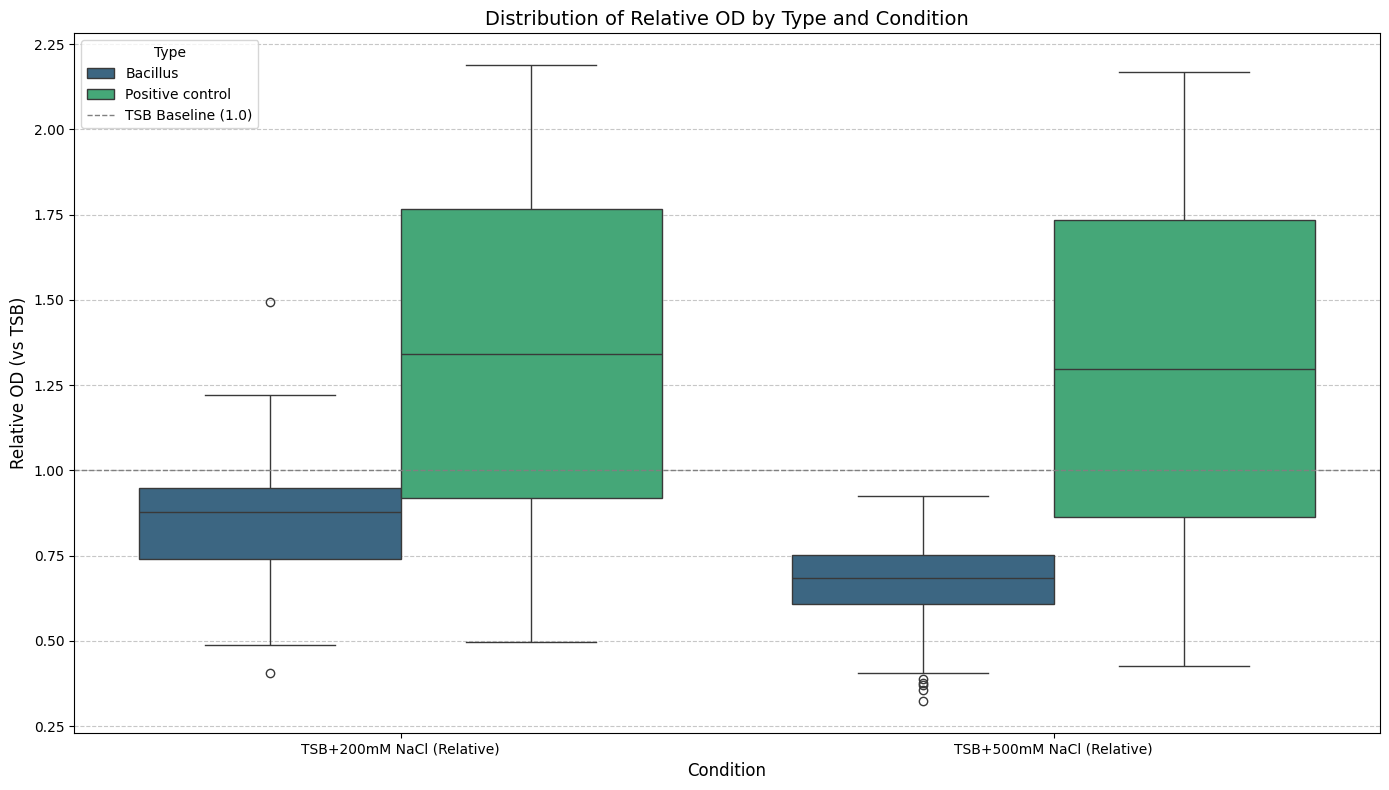

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axes for the box plot
fig, ax = plt.subplots(figsize=(14, 8))

# Use seaborn.boxplot to visualize the distribution of Relative_OD
# 'Condition' will be on the x-axis, 'Relative_OD' on the y-axis
# 'hue' will differentiate between 'Type' (Bacillus vs Positive control)
sns.boxplot(x='Condition', y='Relative_OD', hue='Type', data=plot_data, palette='viridis', ax=ax)

# Set labels and title
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Relative OD (vs TSB)', fontsize=12)
ax.set_title('Distribution of Relative OD by Type and Condition', fontsize=14)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='TSB Baseline (1.0)') # Add TSB baseline
ax.legend(title='Type', fontsize=10) # Add legend for Type
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()